# Simulate and Plot Ventilator Waveforms with Bellows

This notebook uses `bellows` as a Python library. It focuses on simulation setup, waveform plotting, pressure-volume loops, and comparing scenarios.

Run it from the repository root with the editable package installed, or select a kernel where `bellows` is installed.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt

from bellows.simulation.engine import VentilationSimulation
from bellows.simulation.lung_model import LinearLung, VenegasLung
from bellows.simulation.runner import run_samples
from bellows.simulation.state import PatientMechanics, VentilatorSettings

## Small Plotting Helpers

In [2]:
def run_case(settings, patient, *, seconds=12.0, dt_s=0.01):
    simulation = VentilationSimulation(settings=settings, patient=patient)
    samples = run_samples(simulation, seconds=seconds, dt_s=dt_s)
    return simulation, samples


def series(samples, attr):
    return [getattr(sample, attr) for sample in samples]


def latest_complete_breath(samples):
    breaths = sorted({sample.breath for sample in samples}, reverse=True)
    for breath in breaths:
        breath_samples = [sample for sample in samples if sample.breath == breath]
        phases = {sample.phase for sample in breath_samples}
        if {"inspiration", "expiration"}.issubset(phases):
            return breath, breath_samples
    raise ValueError("No complete breath with inspiration and expiration samples")


def plot_waveforms(samples, *, title):
    time_s = series(samples, "time_s")

    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7))
    axes[0].plot(time_s, series(samples, "pressure_cm_h2o"), color="tab:orange")
    axes[0].set_ylabel("Pressure\ncmH2O")
    axes[1].plot(time_s, series(samples, "flow_l_min"), color="tab:blue")
    axes[1].axhline(0, color="0.8", linewidth=0.8)
    axes[1].set_ylabel("Flow\nL/min")
    axes[2].plot(time_s, series(samples, "volume_ml"), color="tab:green")
    axes[2].set_ylabel("Volume\nmL")
    axes[2].set_xlabel("Time, s")

    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes


def plot_pv_loop(samples, *, breath=None, title="Pressure-volume loop"):
    if breath is None:
        breath, breath_samples = latest_complete_breath(samples)
    else:
        breath_samples = [sample for sample in samples if sample.breath == breath]
    inspiration = [sample for sample in breath_samples if sample.phase == "inspiration"]
    expiration = [sample for sample in breath_samples if sample.phase == "expiration"]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(
        series(inspiration, "volume_ml"),
        series(inspiration, "pressure_cm_h2o"),
        label="inspiration",
        color="tab:orange",
        linewidth=2.5,
        alpha=0.75,
        zorder=2,
    )
    ax.plot(
        series(expiration, "volume_ml"),
        series(expiration, "pressure_cm_h2o"),
        label="expiration",
        color="tab:brown",
        linewidth=2.0,
        alpha=0.95,
        linestyle="--",
        zorder=3,
    )
    ax.set_xlabel("Volume, mL")
    ax.set_ylabel("Airway pressure, cmH2O")
    ax.set_title(f"{title} - breath {breath}")
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig, ax

## Build and Run a Pressure-Control Case

The simulation is just Python objects: settings, patient mechanics, and a `VentilationSimulation`.

In [3]:
settings = VentilatorSettings(
    mode="PCV",
    rr_bpm=16.0,
    pinsp_cm_h2o=18.0,
    peep_cm_h2o=6.0,
    ie_i=1.0,
    ie_e=2.0,
)

patient = PatientMechanics(
    lung_model=LinearLung(compliance_l_per_cm_h2o=0.035),
    resistance_cm_h2o_s_per_l=12.0,
    etco2_kpa=5.4,
)

simulation, samples = run_case(settings, patient, seconds=12.0)
len(samples), simulation.last_breath_summary

(1200,
 BreathSummary(breath=2, start_time_s=7.509999999999883, end_time_s=11.259999999999804, min_volume_l=0.21524416698745127, max_volume_l=0.8063889582595524, peak_pressure_cm_h2o=23.999999999999996, etco2_kpa=5.399999999999966))

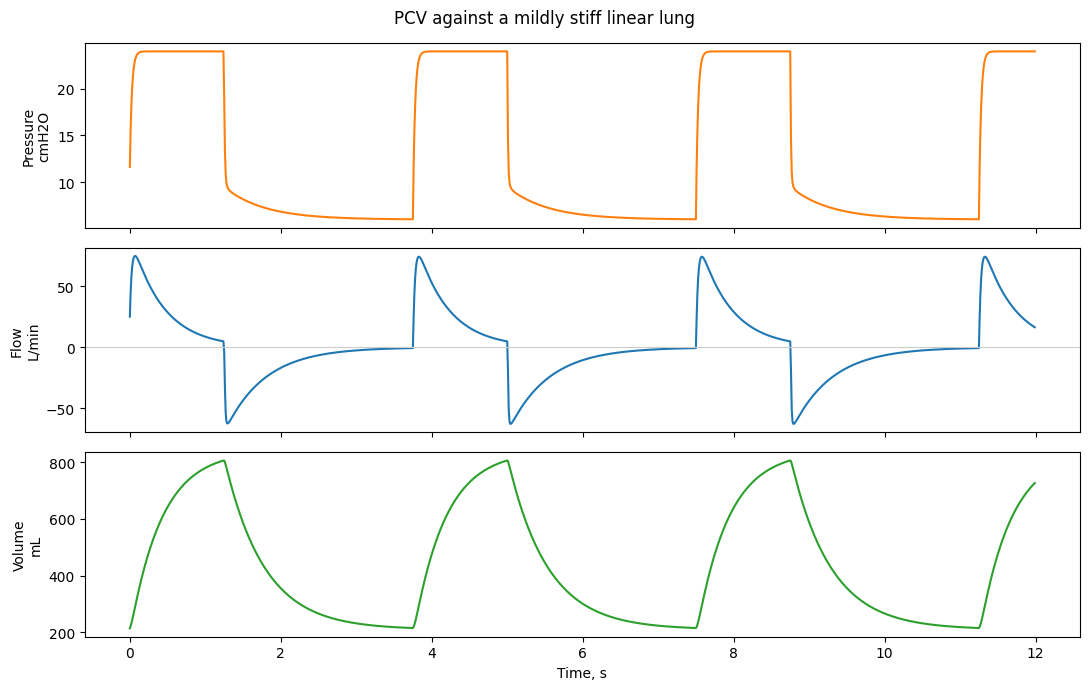

In [4]:
plot_waveforms(samples, title="PCV against a mildly stiff linear lung");

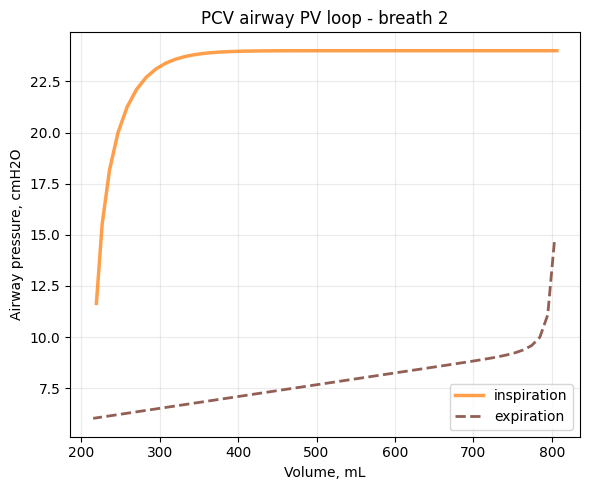

In [5]:
plot_pv_loop(samples, title="PCV airway PV loop");

## Compare Patient Mechanics

Here the ventilator settings stay fixed while the patient model changes. A stiffer lung should produce lower volume for the same pressure target.

In [6]:
normal_patient = PatientMechanics(lung_model=LinearLung(0.05), resistance_cm_h2o_s_per_l=10.0)
stiff_patient = PatientMechanics(lung_model=LinearLung(0.025), resistance_cm_h2o_s_per_l=10.0)

normal_sim, normal_samples = run_case(settings, normal_patient, seconds=12.0)
stiff_sim, stiff_samples = run_case(settings, stiff_patient, seconds=12.0)

normal_summary = normal_sim.last_breath_summary
stiff_summary = stiff_sim.last_breath_summary

{
    "normal_vt_ml": normal_summary.vt_ml,
    "normal_peak_pressure": normal_summary.peak_pressure_cm_h2o,
    "stiff_vt_ml": stiff_summary.vt_ml,
    "stiff_peak_pressure": stiff_summary.peak_pressure_cm_h2o,
}

{'normal_vt_ml': 806.195781688021,
 'normal_peak_pressure': 23.999999999999996,
 'stiff_vt_ml': 446.4745643210035,
 'stiff_peak_pressure': 23.999999999999996}

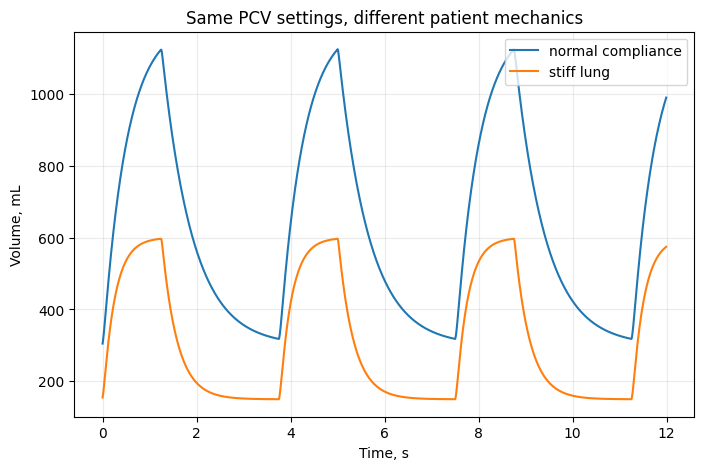

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(series(normal_samples, "time_s"), series(normal_samples, "volume_ml"), label="normal compliance")
ax.plot(series(stiff_samples, "time_s"), series(stiff_samples, "volume_ml"), label="stiff lung")
ax.set_xlabel("Time, s")
ax.set_ylabel("Volume, mL")
ax.set_title("Same PCV settings, different patient mechanics")
ax.legend()
ax.grid(True, alpha=0.25);

## Compare a Recruitable Lung at Different PEEP

The Venegas model has a nonlinear pressure-volume curve. Raising PEEP can move the lung onto a different part of that curve.

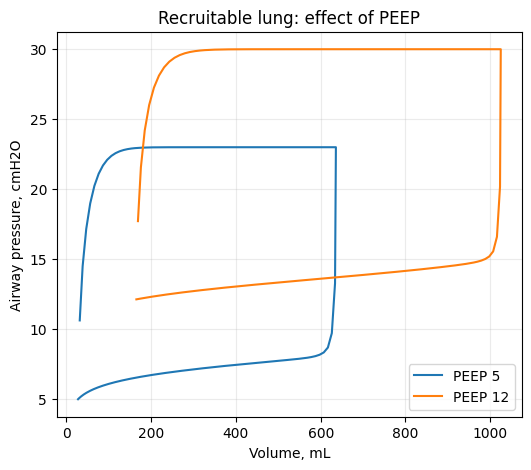

In [8]:
recruitable_patient = PatientMechanics(
    lung_model=VenegasLung(
        inflection_cm_h2o=20.0,
        slope_width_cm_h2o=4.0,
        recruitable_volume_l=1.2,
    ),
    resistance_cm_h2o_s_per_l=12.0,
)

low_peep_settings = replace(settings, peep_cm_h2o=5.0)
higher_peep_settings = replace(settings, peep_cm_h2o=12.0)

_low_sim, low_peep_samples = run_case(low_peep_settings, recruitable_patient, seconds=12.0)
_high_sim, higher_peep_samples = run_case(higher_peep_settings, recruitable_patient, seconds=12.0)

fig, ax = plt.subplots(figsize=(6, 5))
_low_breath, low_loop = latest_complete_breath(low_peep_samples)
_high_breath, high_loop = latest_complete_breath(higher_peep_samples)
ax.plot(series(low_loop, "volume_ml"), series(low_loop, "pressure_cm_h2o"), label="PEEP 5")
ax.plot(series(high_loop, "volume_ml"), series(high_loop, "pressure_cm_h2o"), label="PEEP 12")
ax.set_xlabel("Volume, mL")
ax.set_ylabel("Airway pressure, cmH2O")
ax.set_title("Recruitable lung: effect of PEEP")
ax.legend()
ax.grid(True, alpha=0.25);

## Queue a Settings Change During a Run

The simulator applies ventilator setting changes at a breath boundary. `step_many()` returns all substep samples generated inside a larger time step, including boundary samples.

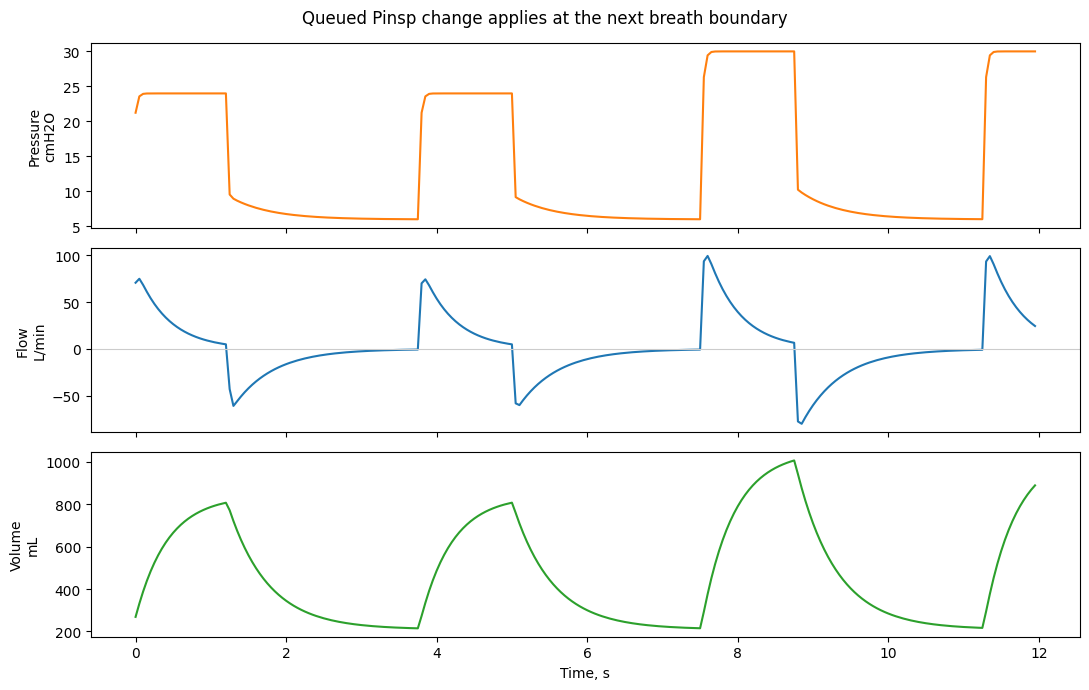

In [9]:
changing_sim = VentilationSimulation(settings=settings, patient=patient)
changing_samples = []

while changing_sim.time_s < 5.0:
    changing_samples.extend(changing_sim.step_many(0.05))

changing_sim.queue_settings(replace(changing_sim.settings, pinsp_cm_h2o=24.0))

while changing_sim.time_s < 12.0:
    changing_samples.extend(changing_sim.step_many(0.05))

plot_waveforms(changing_samples, title="Queued Pinsp change applies at the next breath boundary");